In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # pick GPU #1
import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))  # this will now refer to the selected GPU


1
NVIDIA GeForce RTX 2080 Ti


In [2]:
import sys
import os
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Change working directory to project root
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

Working directory: /mnt/sda/david/activeAuditing/ACL_biasinbios/AuditMeIfYouCan


In [4]:
import os
import wandb
import argparse
from blackboxes.blackbox_api_bias_in_bios import BiasInBiosBlackBox
from config import AuditConfig
from data_loader import load_jigsaw, load_sbic_and_train_api_df
from surrogate_model import (compute_group_auc_difference,
                             load_lora_bert_surrogate, predict_with_model,
                             train_surrogate)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

from sklearn.metrics import roc_auc_score; from scipy.stats import spearmanr
from tqdm import tqdm

import time
from typing import Dict, List, Tuple#
import surrogate_model
import numpy as np
import pandas as pd
import wandb

from torch.nn.functional import sigmoid, softmax

/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-02 16:47:30.519748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767368850.540214  452790 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767368850.546028  452790 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767368850.561428  452790 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more th

In [5]:
from optimization import eval_h, compute_lora_gradient

import utils                      # import the module object
                     # reloads utils.py

# IMPORTANT: rebind the names you use, because `from utils import X`
# copies references that won't update automatically on reload.
from utils import (
    delta_progress,
    df_map,
    stratified_sampling,
    plot_weight_evolution,
    random_ordered_sampling,
    stratified_ordered_sampling,
)
import time
import numpy as np
import pandas as pd
import torch

from dataclasses import dataclass
from typing import Callable, Dict, Any, Tuple, List

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

In [6]:
import os, random
import numpy as np
import torch

def set_all_seeds(seed: int):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # determinism (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


## BASELINES HELPERS


In [7]:
class BiasInBiosScoreAPI:
    """
    Makes BiasInBiosBlackBox look like your Jigsaw api:
      api.predict_scores(list_of_texts) -> np.array(scores)
    Here, "texts" are actually IDs (strings like "ID123").
    """
    def __init__(self, bb, pos_label: str):
        self.bb = bb
        self.pos_label = str(pos_label)

    def predict_scores(self, ids, batch_size: int = 4096):
        if isinstance(ids, str):
            return np.array([self.bb.get_score_for_label(ids, self.pos_label)], dtype=np.float32)

        ids = list(ids)
        out = np.empty(len(ids), dtype=np.float32)
        for i in range(0, len(ids), batch_size):
            chunk = ids[i:i+batch_size]
            # fast path: vectorized lookup via query_distribution then pick column
            # but simplest/robust: loop per id
            for j, sid in enumerate(chunk):
                out[i + j] = self.bb.get_score_for_label(str(sid), self.pos_label)
        return out

In [7]:
def initialize_dataset_S(k_init, D_df, api, seed=0, stratified=True,
                         id_col="id", group_col="group", ref_group=0, comp_group=1):
    rng = np.random.default_rng(seed)
    D_df = D_df.copy().reset_index(drop=True)

    if id_col not in D_df.columns:
        # create stable ids if missing
        D_df[id_col] = np.arange(len(D_df))

    if stratified and (group_col in D_df.columns) and k_init >= 2:
        idx0 = D_df.index[D_df[group_col] == ref_group].to_numpy()
        idx1 = D_df.index[D_df[group_col] == comp_group].to_numpy()
        rng.shuffle(idx0); rng.shuffle(idx1)
        half = k_init // 2
        init_idx = np.concatenate([idx0[:half], idx1[:k_init-half]])
        if len(init_idx) < k_init:
            remaining = np.setdiff1d(np.arange(len(D_df)), init_idx, assume_unique=False)
            extra = rng.choice(remaining, size=k_init-len(init_idx), replace=False)
            init_idx = np.concatenate([init_idx, extra])
    else:
        init_idx = rng.choice(len(D_df), size=min(k_init, len(D_df)), replace=False)

    S = D_df.iloc[init_idx].copy().reset_index(drop=True)
    scores = api.predict_scores(S["text"].tolist())
    S["bb_score"] = np.asarray(scores, dtype=float)
    return S

In [8]:
def make_inputs_from_mapped(df_mapped):
    return {
        "input_ids": torch.tensor(df_mapped["input_ids"]).long(),
        "attention_mask": torch.tensor(df_mapped["attention_mask"]).long(),
        "labels": torch.tensor(df_mapped["labels"]).long(),
        "id": df_mapped["id"],
    }



In [9]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

@torch.no_grad()
def compute_embeddings(texts, model_name="sentence-transformers/all-MiniLM-L6-v2",
                       batch_size=64, device=None, max_length=256):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tok = AutoTokenizer.from_pretrained(model_name)
    enc = AutoModel.from_pretrained(model_name).to(device).eval()

    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        t = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        out = enc(**t).last_hidden_state  # (B, T, H)

        # mean pooling (masked)
        mask = t["attention_mask"].unsqueeze(-1)  # (B, T, 1)
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        embs.append(pooled.detach().cpu())

    embs = torch.cat(embs, dim=0).numpy().astype(np.float32)
    return embs


In [10]:
import os, random
import numpy as np
import torch

def set_all_seeds(seed: int):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # determinism (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

def fit_fast_surrogate(texts, y):
    # robustify inputs
    texts = ["" if (t is None or (isinstance(t, float) and np.isnan(t))) else str(t) for t in texts]
    model = make_pipeline(
        TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2),
        Ridge(alpha=1.0, random_state=0)
    )
    model.fit(texts, y)
    return model

def surrogate_predict(model, texts):
    # ridge can go outside [0,1], clip
    pred = model.predict(texts)
    return np.clip(pred, 0.0, 1.0)


In [12]:
def batched_predict(api_predict_fn, texts, batch_size=16):
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        s = api_predict_fn(batch)
        scores.extend(list(s))
    return np.asarray(scores, dtype=float)


In [13]:
def power_sample_indices(utilities, k, gamma=2.0, eps=1e-8, rng=None):
    rng = rng or np.random.default_rng()
    u = np.maximum(utilities, 0.0) + eps
    w = np.power(u, gamma)
    w = w / w.sum()
    return rng.choice(len(utilities), size=min(k, len(utilities)), replace=False, p=w)


In [14]:
def power_ordered_sampling(D, api_predict_fn, seed=0, k_batch=16, gamma=2.0,
                           init_df=None, id_col="id"):
    """
    Returns an ordering over D, starting from init_df (e.g., S of size 4),
    then selecting batches of k_batch using power sampling.
    """
    rng = np.random.default_rng(seed)
    D = D.copy().reset_index(drop=True)

    if id_col not in D.columns:
        D[id_col] = np.arange(len(D))

    # --- init from init_df if given, else pick 4 random
    if init_df is not None:
        init_ids = set(init_df[id_col].tolist())
        chosen_idx = D.index[D[id_col].isin(init_ids)].to_numpy()
        if len(chosen_idx) == 0:
            raise ValueError("init_df ids not found in D")
        chosen = chosen_idx.tolist()
        # make sure scores exist for chosen
        if "bb_score" in init_df.columns:
            # map init_df scores into D order
            id2s = dict(zip(init_df[id_col].tolist(), init_df["bb_score"].tolist()))
            init_scores = np.array([id2s[D.loc[i, id_col]] for i in chosen], dtype=float)
        else:
            init_scores = np.asarray(api_predict_fn(D.loc[chosen, "text"].tolist()), dtype=float)
    else:
        chosen = rng.choice(len(D), size=4, replace=False).astype(int).tolist()
        init_scores = np.asarray(api_predict_fn(D.loc[chosen, "text"].tolist()), dtype=float)

    scores_map = {int(i): float(s) for i, s in zip(chosen, init_scores)}
    remaining = np.array([i for i in range(len(D)) if i not in set(chosen)], dtype=int)

    # fit initial surrogate
    init_texts = D.loc[chosen, "text"].tolist()
    model = fit_fast_surrogate(init_texts, init_scores)

    # iterative selection
    while len(remaining) > 0:
        rem_texts = D.loc[remaining, "text"].tolist()
        rem_texts = ["" if (t is None or (isinstance(t, float) and np.isnan(t))) else str(t) for t in rem_texts]

        mu = model.predict(rem_texts)
        # "power" utility: push toward extremes (or boundary) depending on your earlier def
        # Here: emphasize boundary-ish points (close to 0.5) by using mu*(1-mu), then power gamma
        util = (mu * (1 - mu)) ** gamma

        k = min(k_batch, len(remaining))
        pick_local = np.argpartition(-util, kth=k-1)[:k]
        sel = remaining[pick_local].astype(int)

        sel_scores = np.asarray(api_predict_fn(D.loc[sel, "text"].tolist()), dtype=float)
        for i, s in zip(sel.tolist(), sel_scores.tolist()):
            scores_map[int(i)] = float(s)

        chosen.extend(sel.tolist())
        remaining = np.setdiff1d(remaining, sel, assume_unique=False)

        # refit surrogate on all chosen so far (fast baseline)
        train_texts = D.loc[chosen, "text"].tolist()
        train_scores = np.array([scores_map[i] for i in chosen], dtype=float)
        model = fit_fast_surrogate(train_texts, train_scores)

    ordered_df = D.iloc[chosen].reset_index(drop=True)
    ordered_scores = np.array([scores_map[i] for i in chosen], dtype=float)
    return ordered_df, ordered_scores

In [15]:
import gpytorch
import torch

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=train_x.shape[-1])
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [16]:
def fit_gp(train_x, train_y, device="cpu", iters=60, lr=0.1):
    train_x = train_x.to(device)
    train_y = train_y.to(device)

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = ExactGPModel(train_x, train_y, likelihood).to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(iters):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    likelihood.eval()
    return model, likelihood


In [17]:
def bo_gp_ordered_sampling(D, X_emb, api_predict_fn, seed=0, k_batch=16,
                           init_size=4, kappa=1.0, gp_train_iters=60,
                           device="cpu", init_df=None, id_col="id"):
    rng = np.random.default_rng(seed)
    D = D.copy().reset_index(drop=True)

    if id_col not in D.columns:
        D[id_col] = np.arange(len(D))

    # --- choose init
    if init_df is not None:
        init_ids = set(init_df[id_col].tolist())
        chosen = D.index[D[id_col].isin(init_ids)].to_numpy().astype(int).tolist()
        if len(chosen) == 0:
            raise ValueError("init_df ids not found in D")
    else:
        chosen = rng.choice(len(D), size=min(init_size, len(D)), replace=False).astype(int).tolist()

    # guard
    if len(chosen) == 0:
        raise ValueError("BO-GP init set is empty")

    # --- query init
    init_texts = D.loc[chosen, "text"].tolist()
    if len(init_texts) == 0:
        raise ValueError("init_texts empty (check chosen / D indexing)")
    init_scores = api_predict_fn(init_texts)
    init_scores = np.asarray(init_scores, dtype=np.float32)

    scores_map = {int(i): float(s) for i, s in zip(chosen, init_scores)}
    remaining = np.array([i for i in range(len(D)) if i not in set(chosen)], dtype=int)

    # helper to rebuild train tensors
    def get_train_tensors():
        x = torch.from_numpy(X_emb[chosen]).float()
        y = torch.tensor([scores_map[i] for i in chosen], dtype=torch.float32)
        # stabilize: z-score y (helps GP); keep for acquisition in [0,1] via inverse later
        y_mean = y.mean()
        y_std = y.std().clamp(min=1e-6)
        yz = (y - y_mean) / y_std
        return x, y, yz, y_mean, y_std

    # --- BO loop
    while len(remaining) > 0:
        train_x, train_y, train_yz, y_mean, y_std = get_train_tensors()
        model, likelihood = fit_gp(train_x, train_yz, device=device, iters=gp_train_iters, lr=0.1)

        # predict on remaining
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            Xrem = torch.from_numpy(X_emb[remaining]).float().to(device)
            pred = likelihood(model(Xrem))
            mu_z = pred.mean
            var_z = pred.variance.clamp(min=1e-9)
            sigma_z = torch.sqrt(var_z)

            # map mean back to score-space approx
            mu = (mu_z * y_std.to(device) + y_mean.to(device)).clamp(0.0, 1.0)
            sigma = (sigma_z * y_std.to(device)).clamp(min=1e-9)

            # acquisition: boundary + uncertainty
            boundary = mu * (1.0 - mu)
            acq = boundary + kappa * sigma

            # pick top batch
            k = min(k_batch, len(remaining))
            topk = torch.topk(acq, k=k, largest=True).indices.detach().cpu().numpy()
            sel_idx = remaining[topk].astype(int)

        # query bb for selected
        sel_texts = D.loc[sel_idx, "text"].tolist()
        sel_scores = api_predict_fn(sel_texts)
        sel_scores = np.asarray(sel_scores, dtype=np.float32)

        for i, s in zip(sel_idx, sel_scores):
            scores_map[int(i)] = float(s)

        chosen.extend(list(sel_idx))
        remaining = np.setdiff1d(remaining, sel_idx, assume_unique=False)

    ordered_df = D.iloc[chosen].reset_index(drop=True)
    ordered_scores = np.array([scores_map[i] for i in chosen], dtype=float)
    return ordered_df, ordered_scores


In [18]:
def tiny_stratified_init_indices(D, group_col="group", ref_group=0, comp_group=1, init_size=4, seed=0):
    rng = np.random.default_rng(seed)
    idx0 = D.index[D[group_col] == ref_group].to_numpy()
    idx1 = D.index[D[group_col] == comp_group].to_numpy()
    rng.shuffle(idx0); rng.shuffle(idx1)
    half = init_size // 2
    return np.concatenate([idx0[:half], idx1[:init_size-half]]).astype(int)


In [19]:
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score




#  FAIRNESS METRIC: ΔAUC 

def compute_delta_auc(df, score_col='bb_score', group_col='group', ref_group=0, comp_group=1):
    """
    Compute ΔAUC = AUC(ref_group) - AUC(comp_group) between two groups.
    Handles invalid/missing data safely.
    """
    try:
        for c in (score_col, group_col, 'labels'):
            if c not in df.columns:
                warnings.warn(f"Column '{c}' not found in dataframe")
                return np.nan

        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[score_col, 'labels', group_col])
        if len(df) < 10:
            return np.nan

        groups_present = set(df[group_col].unique().tolist())
        if not ({ref_group, comp_group} <= groups_present):
            warnings.warn(f"Groups {ref_group}, {comp_group} not both present")
            return np.nan

        def auc_for(g):
            sub = df[df[group_col] == g]
            if len(sub) < 4:
                return np.nan
            n_pos = (sub['labels'] == 1).sum()
            n_neg = (sub['labels'] == 0).sum()
            if n_pos < 2 or n_neg < 2:
                return np.nan
            return roc_auc_score(sub['labels'], sub[score_col])

        auc_ref = auc_for(ref_group)
        auc_cmp = auc_for(comp_group)
        if np.isnan(auc_ref) or np.isnan(auc_cmp):
            return np.nan
        if not (0 <= auc_ref <= 1 and 0 <= auc_cmp <= 1):
            return np.nan
        return float(auc_ref - auc_cmp)

    except Exception as e:
        warnings.warn(f"Error computing ΔAUC: {str(e)}")
        return np.nan


In [20]:
def stepwise_delta_auc_with_init(ordered_df, scores, k_init=4, k_batch=16,
                                 true_delta=None, ref_group=0, comp_group=1,
                                 include_init_point=True):
    """
    ordered_df/scores should be in the exact query order:
      first k_init correspond to S, then batches of k_batch.
    Logs at n_queries = k_init (optional), k_init+k_batch, k_init+2*k_batch, ...
    """
    df_with_scores = ordered_df.copy()
    df_with_scores["bb_score"] = scores

    rows = []
    if include_init_point and k_init <= len(df_with_scores):
        sub = df_with_scores.iloc[:k_init]
        est = compute_delta_auc(sub, ref_group=ref_group, comp_group=comp_group)
        err = np.nan if true_delta is None or np.isnan(est) else abs(est - true_delta)
        rows.append({"n_queries": k_init, "delta_auc_est": est, "error": err})

    n = k_init + k_batch
    while n <= len(df_with_scores):
        sub = df_with_scores.iloc[:n]
        est = compute_delta_auc(sub, ref_group=ref_group, comp_group=comp_group)
        err = np.nan if true_delta is None or np.isnan(est) else abs(est - true_delta)
        rows.append({"n_queries": n, "delta_auc_est": est, "error": err})
        n += k_batch

    return pd.DataFrame(rows)


In [21]:
def prepend_S_to_ordered_run(S, ordered_df_rest, scores_S, scores_rest, id_col="id"):
    # sanity: ensure no overlap
    S_ids = set(S[id_col].tolist())
    rest = ordered_df_rest[~ordered_df_rest[id_col].isin(S_ids)].copy()

    # concatenate in query order
    ordered = pd.concat([S.reset_index(drop=True), rest.reset_index(drop=True)], ignore_index=True)
    scores = np.concatenate([np.asarray(scores_S, float), np.asarray(scores_rest, float)])
    return ordered, scores


In [22]:
def random_after_S(dataset_D, S, api_predict_fn, seed=0, id_col="id"):
    rng = np.random.default_rng(seed)
    S_ids = set(S[id_col].tolist())

    rest = dataset_D[~dataset_D[id_col].isin(S_ids)].copy()
    perm = rng.permutation(len(rest))
    rest = rest.iloc[perm].reset_index(drop=True)

    scores_rest = api_predict_fn(rest["text"].tolist())
    scores_S = S["bb_score"].to_numpy()  # already queried in initialize_dataset_S
    ordered, scores = prepend_S_to_ordered_run(S, rest, scores_S, scores_rest, id_col=id_col)
    return ordered, scores


In [23]:
def stratified_after_S(dataset_D, S, api_predict_fn, seed=0,
                       id_col="id", group_col="group", ref_group=0, comp_group=1):
    rng = np.random.default_rng(seed)
    S_ids = set(S[id_col].tolist())
    rest = dataset_D[~dataset_D[id_col].isin(S_ids)].copy()

    # simple alternating stratified ordering (like your util)
    g0 = rest[rest[group_col] == ref_group].copy()
    g1 = rest[rest[group_col] == comp_group].copy()
    g0 = g0.sample(frac=1, random_state=seed).reset_index(drop=True)
    g1 = g1.sample(frac=1, random_state=seed+1).reset_index(drop=True)

    rows = []
    i0 = i1 = 0
    while i0 < len(g0) or i1 < len(g1):
        if i0 < len(g0):
            rows.append(g0.iloc[i0]); i0 += 1
        if i1 < len(g1):
            rows.append(g1.iloc[i1]); i1 += 1

    rest_ordered = pd.DataFrame(rows).reset_index(drop=True)
    scores_rest = api_predict_fn(rest_ordered["text"].tolist())

    scores_S = S["bb_score"].to_numpy()
    ordered, scores = prepend_S_to_ordered_run(S, rest_ordered, scores_S, scores_rest, id_col=id_col)
    return ordered, scores


In [24]:
def power_after_S(dataset_D, S, api_predict_fn, seed=0, k_batch=16, gamma=2.0, id_col="id"):
    return power_ordered_sampling(
        dataset_D, api_predict_fn,
        seed=seed, k_batch=k_batch, gamma=gamma,
        init_df=S, id_col=id_col
    )


In [25]:
def bo_gp_after_S(dataset_D, S, X_emb, api_predict_fn, seed=0, k_batch=16,
                  id_col="id", kappa=1.0, gp_train_iters=60):
    # run BO-GP directly on the full dataset but starting from S
    return bo_gp_ordered_sampling(
        dataset_D, X_emb, api_predict_fn,
        seed=seed, k_batch=k_batch,
        init_size=len(S),  # unused if init_df provided, but harmless
        kappa=kappa, gp_train_iters=gp_train_iters,
        init_df=S, id_col=id_col
    )


In [26]:
def ensure_int_groups(df: pd.DataFrame, group_col="group"):
    """
    Ensures df[group_col] is integer-coded. If strings, maps {"white":0,"black":1}.
    Returns (df, mapping_or_None).
    """
    df = df.copy()
    if group_col not in df.columns:
        raise ValueError(f"Missing column '{group_col}'")

    if not np.issubdtype(df[group_col].dtype, np.integer):
        mapping = {"white": 0, "black": 1}
        missing = set(df[group_col].unique()) - set(mapping.keys())
        if missing:
            raise ValueError(f"Group labels {missing} not covered by mapping {mapping}")
        df[group_col] = df[group_col].map(mapping).astype(int)
        print(f"[INFO] Using explicit group mapping: {mapping}")
        return df, mapping
    else:
        return df, None

## BASELINE CALCULATION

In [8]:
def build_bios_D(scores_csv: str, pos_label: str):
    """
    Produces D with columns compatible with baselines_jigsaw.ipynb:
      - text: (here) id string
      - true_label: binary one-vs-rest (gold == pos_label)
      - group: gender (int)
    """
    bb = BiasInBiosBlackBox(scores_csv, verbose=True)

    rows = []
    for sid in bb.ids:
        gold = bb.get_gold_label(sid)
        gender = bb.get_gender(sid)
        if gold is None or gender is None:
            continue

        y = 1 if str(gold) == str(pos_label) else 0
        rows.append(
            {
                "id": str(sid),
                "text": str(sid),           # IMPORTANT: reuse utils samplers
                "true_label": int(y),
                "group": int(gender),
                "gold_occupation": str(gold),
            }
        )

    D = pd.DataFrame(rows).reset_index(drop=True)
    api = BiasInBiosScoreAPI(bb, pos_label=pos_label)
    return D, api, bb

In [27]:
def make_inputs_from_mapped(df_mapped):
    return {
        "input_ids": torch.tensor(df_mapped["input_ids"]).long(),
        "attention_mask": torch.tensor(df_mapped["attention_mask"]).long(),
        "labels": torch.tensor(df_mapped["labels"]).long(),
        "id": df_mapped["id"],
    }


In [ ]:
def run_trial_with_bb_and_surrogate_init(
    dataset_D, D, df_D_mapped, inputs_D, tokenizer,
    seed: int,
    k_batch: int = 16,
    k_init: int = 4,
    ref_group: int = 0,
    comp_group: int = 1,
    scores_csv: str = "blackboxes/blackbox_bios.csv",
    flip_probs=None,
    bb_epochs: int = 4,
    bb_batch_size: int = 32,
    bb_lr: float = 2e-5,
    X_emb=None,   # for BO-GP if you use it
):
    # --- Ensure integer group mapping on the audit dataset
    dataset_D2, group_mapping = ensure_int_groups(dataset_D, group_col="group")

    # Keep D consistent with dataset_D2 (same rows, same ids)
    D2 = dataset_D2.copy()

    # Ensure an id column exists (stable across trials)
    if "id" not in D2.columns:
        D2["id"] = np.arange(len(D2))

    # --- Fresh black box per seed
    set_all_seeds(seed)
    api = BiasInBiosBlackBox(scores_csv)
    

    # --- Seed S (size 4) from the audit dataset and map it
    S = initialize_dataset_S(
        k_init, D2, api, seed=seed, stratified=True,
        id_col="id", group_col="group", ref_group=ref_group, comp_group=comp_group
    )
    df_S, df_S_mapped = df_map(S, tokenizer, True)
    inputs_S = make_inputs_from_mapped(df_S_mapped)

    # --- Compute seed-specific true ΔAUC on full audit set for THIS black box
    D_full = D2.copy()
    D_full["bb_score"] = api.predict_scores(D_full["text"].tolist())
    true_delta = compute_delta_auc(D_full, ref_group=ref_group, comp_group=comp_group)
    print(f"[Seed {seed}] True ΔAUC on full audit set: {true_delta:.6f}")

    # --- Run strategies AFTER S (budgets: 4, 20, 36, ...)
    out = []

    # Random AFTER S
    rand_D, rand_scores = random_after_S(D2, S, api.predict_scores, seed=seed, id_col="id")
    df = stepwise_delta_auc_with_init(rand_D, rand_scores, k_init=k_init, k_batch=k_batch,
                                      true_delta=true_delta, ref_group=ref_group, comp_group=comp_group)
    df["seed"] = seed; df["strategy"] = "random"
    out.append(df)

    print(f"[Seed {seed}] Completed random strategy")

    # Stratified AFTER S
    strat_D, strat_scores = stratified_after_S(D2, S, api.predict_scores, seed=seed, id_col="id",
                                               group_col="group", ref_group=ref_group, comp_group=comp_group)
    df = stepwise_delta_auc_with_init(strat_D, strat_scores, k_init=k_init, k_batch=k_batch,
                                      true_delta=true_delta, ref_group=ref_group, comp_group=comp_group)
    df["seed"] = seed; df["strategy"] = "stratified"
    out.append(df)

    print(f"[Seed {seed}] Completed stratified strategy")

    # Power AFTER S
    pow_D, pow_scores = pow_D, pow_scores = power_after_S(
    D2, S, api.predict_scores,
    seed=seed, k_batch=k_batch, gamma=2.0, id_col="id"
)
    df = stepwise_delta_auc_with_init(pow_D, pow_scores, k_init=k_init, k_batch=k_batch,
                                      true_delta=true_delta, ref_group=ref_group, comp_group=comp_group)
    df["seed"] = seed; df["strategy"] = "power"
    out.append(df)

    print(f"[Seed {seed}] Completed power strategy")

    # BO-GP AFTER S (optional)
    if X_emb is not None:
        bo_D, bo_scores = bo_gp_after_S(D2, S, X_emb, api.predict_scores, seed=seed, k_batch=k_batch,
                                        id_col="id", kappa=1.0, gp_train_iters=60)
        df = stepwise_delta_auc_with_init(bo_D, bo_scores, k_init=k_init, k_batch=k_batch,
                                          true_delta=true_delta, ref_group=ref_group, comp_group=comp_group)
        df["seed"] = seed; df["strategy"] = "bo_gp"
        out.append(df)
        print(f"[Seed {seed}] Completed BO-GP strategy")

    df_seed = pd.concat(out, ignore_index=True)
    df_seed["true_delta"] = true_delta
    df_seed["group_mapping_used"] = str(group_mapping) if group_mapping is not None else ""

    return df_seed, api, (S, df_S, df_S_mapped, inputs_S)

In [ ]:

# ============================================================
# === MAIN EXPERIMENT (same shape as notebook)
# ============================================================

# --- CONFIG ---
SCORES_CSV = "blackbox_bios.csv"            # <-- change if needed
POS_LABEL  = "software_engineer"           # <-- choose your one-vs-rest label
ref_group, comp_group = 0, 1               # gender groups
n_trials = 10                              # seeds
seed0 = 22

# --- Load D + API ---
D, api, bb = build_bios_D(SCORES_CSV, pos_label=POS_LABEL)

# align with notebook: D["labels"] = D["true_label"]
D["labels"] = D["true_label"]

max_queries = len(D)
window_sizes = list(range(5, max_queries + 1, 5))  # exactly like notebook
# If you want to log every "round" like your main experiments, replace with:
# window_sizes = [4] + list(range(20, max_queries + 1, 16))

# Compute true ΔAUC on full dataset (seed-invariant for CSV black-box)
print("Computing true ΔAUC on full dataset...")
D_full_copy = D.copy()
D_full_copy["bb_score"] = api.predict_scores(D_full_copy["text"].tolist())
true_delta = compute_delta_auc(D_full_copy, ref_group=ref_group, comp_group=comp_group)
print(f"True ΔAUC (full dataset, {len(D)} samples): {true_delta:.3f}")
print("=" * 70)

# Run multiple trials
all_results = []

for trial in range(n_trials):
    seed = seed0 + trial
    print(f"Trial {trial+1}/{n_trials} (seed={seed})...", end=" ")
    try:
        res = run_trial(D, api, window_sizes, seed, ref_group, comp_group)
        all_results.append(res)
        print("✓")
    except Exception as e:
        print(f"✗ Failed: {str(e)}")

print("=" * 70)

df_all = pd.concat(all_results, ignore_index=True)

# Save exactly like you described (per strategy in one CSV)
out_dir = "runs_bias_in_bios_baselines_like_jigsaw"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"all_runs_bias_in_bios_POS={POS_LABEL}.csv")
df_all.to_csv(out_path, index=False)
print("Saved:", out_path)

# Compute statistics per strategy
stats = (
    df_all.groupby(["strategy", "n_queries"])["delta_auc"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
stats["se"] = stats["std"] / np.sqrt(stats["count"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/hateBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Parameter 'function'=<function df_map.<locals>.<lambda> at 0x7f47c2384540> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 10000/10000 [00:00<00:00, 12201.29 examples/s]


In [ ]:
import os

D["labels"] = D["true_label"]
ref_group, comp_group = 0, 1
k_batch = 16

# true delta once
D_full = D.copy()
D_full["bb_score"] = api.predict_scores(D_full["text"].tolist())
true_delta = compute_delta_auc(D_full, ref_group=ref_group, comp_group=comp_group)
print("True ΔAUC:", true_delta)

# embeddings once (GPU)
X_emb = compute_embeddings(D["text"].tolist())  # uses GPU if available

seeds = [22+i for i in range(10)]
out_dir = "runs_notebook"
os.makedirs(out_dir, exist_ok=True)

dfs = []
for seed in seeds:
    df_seed = run_trial(D, api, seed, true_delta, X_emb, k_batch=k_batch, ref_group=ref_group, comp_group=comp_group)
    df_seed.to_csv(os.path.join(out_dir, f"seed_{seed}.csv"), index=False)
    dfs.append(df_seed)

df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv(os.path.join(out_dir, "all_runs_4strategies.csv"), index=False)
df_all.head()


  0%|          | 0/313 [00:00<?, ?it/s]

100%|██████████| 313/313 [00:42<00:00,  7.39it/s]


True ΔAUC: -0.09065500048384911


KeyboardInterrupt: 

In [ ]:
def summarize_over_seeds(df_all):
    g = df_all.groupby(["strategy", "n_queries"])["delta_auc_est"].agg(["mean", "std", "count"]).reset_index()
    g["se"] = g["std"] / np.sqrt(g["count"])
    return g

stats = summarize_over_seeds(df_all)

fig, ax = plt.subplots(figsize=(12,6))
for strat in stats["strategy"].unique():
    sub = stats[stats["strategy"] == strat]
    ax.plot(sub["n_queries"], sub["mean"], marker="o", linewidth=2, label=strat)
    ax.fill_between(sub["n_queries"], sub["mean"]-sub["se"], sub["mean"]+sub["se"], alpha=0.2)

ax.axhline(true_delta, linestyle="--", linewidth=2, label=f"true ΔAUC={true_delta:.3f}")
ax.set_xscale("log")
ax.set_xlabel("Queries")
ax.set_ylabel("ΔAUC estimate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


stratified_ordered_sampling

In [ ]:
#  PLOT 


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(stats_random['n_queries'], stats_random['mean'],
        'o-', alpha=0.8, label='Random sampling', linewidth=2.5, color='C0')
ax.fill_between(stats_random['n_queries'],
                stats_random['mean'] - stats_random['se'],
                stats_random['mean'] + stats_random['se'], alpha=0.2, color='C0')

ax.plot(stats_stratified['n_queries'], stats_stratified['mean'],
        's-', alpha=0.8, label='Stratified sampling', linewidth=2.5, color='C1')
ax.fill_between(stats_stratified['n_queries'],
                stats_stratified['mean'] - stats_stratified['se'],
                stats_stratified['mean'] + stats_stratified['se'], alpha=0.2, color='C1')

ax.axhline(y=true_delta, color='red', linestyle='--',
           label=f'True ΔAUC = {true_delta:.3f}', linewidth=2)
ax.axhspan(true_delta - 0.01, true_delta + 0.01, alpha=0.1, color='red', label='±0.01 threshold')

ax.set_xscale('log')
ax.set_xlabel('Query Budget (Number of Samples)', fontsize=12)
ax.set_ylabel('ΔAUC Estimate', fontsize=12)
ax.set_title(f'Active Auditing: Stratified vs. Random Sampling\n(Average over {n_trials} trials, shaded = ±1 SE)',
             fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# === SUMMARY ===============================================
# ============================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

for df, name in [(stats_random, 'Random'), (stats_stratified, 'Stratified')]:
    df_copy = df.copy()
    df_copy['error'] = abs(df_copy['mean'] - true_delta)
    within_threshold = df_copy[df_copy['error'] < 0.01]

    if len(within_threshold) > 0:
        first_convergence = within_threshold.iloc[0]['n_queries']
        pct = first_convergence / max_queries * 100
        conv_std = within_threshold.iloc[0]['std']
        conv_se = within_threshold.iloc[0]['se']
        print(f"{name:12s}: Converged at {int(first_convergence):4d} queries "
              f"({pct:.1f}% of data) [std={conv_std:.3f}, SE={conv_se:.3f}]")
    else:
        print(f"{name:12s}: Did not converge within ±0.01")

print(f"\nTotal dataset size: {max_queries}")
print(f"Number of trials: {n_trials}")
print(f"True ΔAUC (full dataset): {true_delta:.3f}")
print("="*70)

final_random_std = stats_random.iloc[-1]['std']
final_stratified_std = stats_stratified.iloc[-1]['std']
print(f"\nVariance at full budget:")
print(f"  Random:     std = {final_random_std:.4f}")
print(f"  Stratified: std = {final_stratified_std:.4f}")
print(f"  Reduction:  {(1 - final_stratified_std/final_random_std)*100:.1f}%")
print("="*70)

In [ ]:
def compute_summary_stats_over_time_baseline(
    df_all,
    true_delta
):
    """
    df_all: concatenated baseline results
            columns = ['seed', 'n_queries', 'delta_auc']
    """
    df = df_all.copy()
    df["error"] = np.abs(df["delta_auc"] - true_delta)

    grouped = (
        df.groupby("n_queries")["error"]
          .agg(
              mean="mean",
              std="std",
              median="median",
              n="count"
          )
          .reset_index()
          .sort_values("n_queries")
          .rename(columns={"n_queries": "T_size"})
    )

    return grouped


In [ ]:
def per_seed_crossing_times_baseline(
    df_all,
    true_delta,
    epsilon
):
    rows = []

    for seed, seed_df in df_all.groupby("seed"):
        seed_df = seed_df.sort_values("n_queries").copy()
        seed_df["error"] = np.abs(seed_df["delta_auc"] - true_delta)

        crossed = seed_df[seed_df["error"] <= epsilon]
        T_hit = crossed.iloc[0]["n_queries"] if len(crossed) > 0 else None

        rows.append({
            "seed": seed,
            "T_hit": T_hit
        })

    return pd.DataFrame(rows)


In [ ]:
def find_mean_crossing_time(summary_df, epsilon):
    crossed = summary_df[summary_df["mean"] <= epsilon]
    if len(crossed) == 0:
        return None
    return crossed.iloc[0]["T_size"]


In [ ]:
def summarize_query_times(T_hits):
    times = np.array([t for t in T_hits if t is not None])

    if len(times) == 0:
        return {
            "mean_queries": None,
            "median_queries": None,
            "std_queries": None,
            "n_converged": 0
        }

    return {
        "mean_queries": times.mean(),
        "median_queries": np.median(times),
        "std_queries": times.std(ddof=1),
        "n_converged": len(times)
    }


In [ ]:
def error_stats_at_T(summary_df, T_star):
    row = summary_df[summary_df["T_size"] == T_star]
    if len(row) == 0:
        return {
            "mean_error": None,
            "std_error": None,
            "median_error": None,
            "n": 0
        }

    row = row.iloc[0]
    return {
        "mean_error": row["mean"],
        "std_error": row["std"],
        "median_error": row["median"],
        "n": row["n"]
    }


In [ ]:
def compute_full_epsilon_stats_baselines(
    baseline_dfs,          # dict: {"Random": df_random_all, "Stratified": df_stratified_all}
    true_delta,
    epsilon_values
):
    results = []

    for method_name, df_all in baseline_dfs.items():
        print(f"Processing {method_name}...", end=" ")

        summary_df = compute_summary_stats_over_time_baseline(
            df_all, true_delta
        )

        for epsilon in epsilon_values:
            # population-level crossing (mean-first)
            T_star = find_mean_crossing_time(summary_df, epsilon)

            # per-seed query times
            seed_hits = per_seed_crossing_times_baseline(
                df_all, true_delta, epsilon
            )
            query_stats = summarize_query_times(seed_hits["T_hit"])

            # error stats at crossing
            error_stats = (
                error_stats_at_T(summary_df, T_star)
                if T_star is not None else
                {"mean_error": None, "std_error": None, "median_error": None, "n": 0}
            )

            results.append({
                "strategy": method_name,
                "epsilon": epsilon,
                "mean_crossing_T": T_star,

                # query-level stats (per-seed)
                "mean_queries": query_stats["mean_queries"],
                "median_queries": query_stats["median_queries"],
                "std_queries": query_stats["std_queries"],
                "n_converged": query_stats["n_converged"],

                # error-level stats (mean curve)
                "mean_error": error_stats["mean_error"],
                "std_error": error_stats["std_error"],
                "median_error": error_stats["median_error"],
                "n_at_T": error_stats["n"],
            })

        print("✓")

    return pd.DataFrame(results)


In [ ]:
baseline_stats = compute_full_epsilon_stats_baselines(
    baseline_dfs={
        "Random": df_random_all,
        "Stratified": df_stratified_all,
    },
    true_delta=true_delta,
    epsilon_values=[0.02, 0.05]
)

baseline_stats


Processing Random... ✓
Processing Stratified... ✓


,strategy,epsilon,mean_crossing_T,mean_queries,median_queries,std_queries,n_converged,mean_error,std_error,median_error,n_at_T
0,Random,0.02,2815.0,584.000000,145.0,1300.844156,30,0.019711,0.015332,0.014492,30.0
1,Random,0.05,585.0,252.833333,85.0,477.258123,30,0.049499,0.046322,0.036345,30.0
2,Stratified,0.02,1095.0,189.666667,67.5,304.616586,30,0.019750,0.015480,0.016588,30.0
3,Stratified,0.05,305.0,102.333333,30.0,201.326349,30,0.049919,0.034658,0.048574,30.0


In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, List, Optional

# ============================================
# YOUR EXISTING FUNCTIONS (UNCHANGED)
# ============================================

def compute_summary_stats_over_time_baseline(
    df_all,
    true_delta
):
    """
    df_all: concatenated baseline results
            columns = ['seed', 'n_queries', 'delta_auc']
    """
    df = df_all.copy()
    df["error"] = np.abs(df["delta_auc"] - true_delta)
    grouped = (
        df.groupby("n_queries")["error"]
          .agg(
              mean="mean",
              std="std",
              median="median",
              n="count"
          )
          .reset_index()
          .sort_values("n_queries")
          .rename(columns={"n_queries": "T_size"})
    )
    return grouped


def per_seed_crossing_times_baseline(
    df_all,
    true_delta,
    epsilon
):
    rows = []
    for seed, seed_df in df_all.groupby("seed"):
        seed_df = seed_df.sort_values("n_queries").copy()
        seed_df["error"] = np.abs(seed_df["delta_auc"] - true_delta)
        crossed = seed_df[seed_df["error"] <= epsilon]
        T_hit = crossed.iloc[0]["n_queries"] if len(crossed) > 0 else None
        rows.append({
            "seed": seed,
            "T_hit": T_hit
        })
    return pd.DataFrame(rows)


def find_mean_crossing_time(summary_df, epsilon):
    """Find first T where mean error <= epsilon"""
    crossed = summary_df[summary_df["mean"] <= epsilon]
    if len(crossed) == 0:
        return None
    return crossed.iloc[0]["T_size"]


def summarize_query_times(T_hits):
    times = np.array([t for t in T_hits if t is not None])
    if len(times) == 0:
        return {
            "mean_queries": None,
            "median_queries": None,
            "std_queries": None,
            "n_converged": 0
        }
    return {
        "mean_queries": times.mean(),
        "median_queries": np.median(times),
        "std_queries": times.std(ddof=1),
        "n_converged": len(times)
    }


def error_stats_at_T(summary_df, T_star):
    row = summary_df[summary_df["T_size"] == T_star]
    if len(row) == 0:
        return {
            "mean_error": None,
            "std_error": None,
            "median_error": None,
            "n": 0
        }
    row = row.iloc[0]
    return {
        "mean_error": row["mean"],
        "std_error": row["std"],
        "median_error": row["median"],
        "n": row["n"]
    }


# ============================================
# NEW: BOOTSTRAP FUNCTIONS
# ============================================

def bootstrap_mean_crossing_T(
    df_all,
    true_delta,
    epsilon,
    n_bootstrap=1000,
    ci_level=0.95,
    random_state=42
):
    """
    Bootstrap confidence interval for mean_crossing_T.
    
    Parameters:
    -----------
    df_all : DataFrame
        Baseline results with columns ['seed', 'n_queries', 'delta_auc']
    true_delta : float
        Ground truth fairness metric
    epsilon : float
        Convergence threshold
    n_bootstrap : int
        Number of bootstrap samples
    ci_level : float
        Confidence interval level (default: 0.95)
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict with keys: mean, median, ci_lower, ci_upper, n_converged, bootstrap_samples
    """
    np.random.seed(random_state)
    
    # Get unique seeds
    seeds = df_all['seed'].unique()
    n_seeds = len(seeds)
    
    if n_seeds < 3:
        return {
            'mean': None,
            'median': None,
            'ci_lower': None,
            'ci_upper': None,
            'n_converged': 0,
            'bootstrap_samples': []
        }
    
    crossing_Ts = []
    
    for i in range(n_bootstrap):
        # Resample seeds with replacement
        boot_seeds = np.random.choice(seeds, size=n_seeds, replace=True)
        
        # Get data for bootstrapped seeds
        boot_df = df_all[df_all['seed'].isin(boot_seeds)].copy()
        
        # Compute mean curve for this bootstrap sample
        boot_df["error"] = np.abs(boot_df["delta_auc"] - true_delta)
        boot_summary = (
            boot_df.groupby("n_queries")["error"]
                   .mean()
                   .reset_index()
                   .sort_values("n_queries")
                   .rename(columns={"n_queries": "T_size", "error": "mean"})
        )
        
        # Find crossing time
        T_cross = find_mean_crossing_time(boot_summary, epsilon)
        
        if T_cross is not None:
            crossing_Ts.append(T_cross)
    
    if len(crossing_Ts) == 0:
        return {
            'mean': None,
            'median': None,
            'ci_lower': None,
            'ci_upper': None,
            'n_converged': 0,
            'bootstrap_samples': []
        }
    
    crossing_Ts = np.array(crossing_Ts)
    alpha = 1 - ci_level
    
    return {
        'mean': np.mean(crossing_Ts),
        'median': np.median(crossing_Ts),
        'ci_lower': np.percentile(crossing_Ts, 100 * alpha / 2),
        'ci_upper': np.percentile(crossing_Ts, 100 * (1 - alpha / 2)),
        'n_converged': len(crossing_Ts),
        'bootstrap_samples': crossing_Ts.tolist()
    }


# ============================================
# UPDATED: MAIN COMPUTATION WITH BOOTSTRAP
# ============================================

def compute_full_epsilon_stats_baselines(
    baseline_dfs,          # dict: {"Random": df_random_all, "Stratified": df_stratified_all}
    true_delta,
    epsilon_values,
    n_bootstrap=1000,      # NEW parameter
    ci_level=0.95,         # NEW parameter
    random_state=42        # NEW parameter
):
    """
    Compute convergence statistics with bootstrap confidence intervals.
    """
    results = []
    
    for method_name, df_all in baseline_dfs.items():
        print(f"Processing {method_name}...", end=" ")
        
        # Compute summary statistics
        summary_df = compute_summary_stats_over_time_baseline(
            df_all, true_delta
        )
        
        for epsilon in epsilon_values:
            # 1. Population-level crossing (mean-first)
            T_star = find_mean_crossing_time(summary_df, epsilon)
            
            # 2. Bootstrap CI for mean_crossing_T
            boot_stats = bootstrap_mean_crossing_T(
                df_all, true_delta, epsilon, 
                n_bootstrap=n_bootstrap,
                ci_level=ci_level,
                random_state=random_state
            )
            
            # 3. Per-seed query times
            seed_hits = per_seed_crossing_times_baseline(
                df_all, true_delta, epsilon
            )
            query_stats = summarize_query_times(seed_hits["T_hit"])
            
            # 4. Error stats at crossing
            error_stats = (
                error_stats_at_T(summary_df, T_star)
                if T_star is not None else
                {"mean_error": None, "std_error": None, "median_error": None, "n": 0}
            )
            
            results.append({
                "strategy": method_name,
                "epsilon": epsilon,
                
                # Population-level convergence
                "mean_crossing_T": T_star,
                "mean_crossing_T_boot_mean": boot_stats['mean'],
                "mean_crossing_T_boot_median": boot_stats['median'],
                "mean_crossing_T_ci_lower": boot_stats['ci_lower'],
                "mean_crossing_T_ci_upper": boot_stats['ci_upper'],
                "mean_crossing_T_boot_converged": boot_stats['n_converged'],
                
                # Per-seed query-level stats
                "mean_queries": query_stats["mean_queries"],
                "median_queries": query_stats["median_queries"],
                "std_queries": query_stats["std_queries"],
                "n_converged": query_stats["n_converged"],
                
                # Error-level stats at crossing
                "mean_error": error_stats["mean_error"],
                "std_error": error_stats["std_error"],
                "median_error": error_stats["median_error"],
                "n_at_T": error_stats["n"],
            })
        
        print("✓")
    
    return pd.DataFrame(results)


# ============================================
# RUN YOUR ANALYSIS (WITH BOOTSTRAP)
# ============================================

baseline_stats = compute_full_epsilon_stats_baselines(
    baseline_dfs={
        "Random": df_random_all,
        "Stratified": df_stratified_all,
    },
    true_delta=true_delta,
    epsilon_values=[0.02, 0.05],
    n_bootstrap=1000,      # 1000 bootstrap samples
    ci_level=0.95,         # 95% CI
    random_state=42        # for reproducibility
)

display(baseline_stats)

Processing Random... ✓
Processing Stratified... ✓


,strategy,epsilon,mean_crossing_T,mean_crossing_T_boot_mean,mean_crossing_T_boot_median,mean_crossing_T_ci_lower,mean_crossing_T_ci_upper,mean_crossing_T_boot_converged,mean_queries,median_queries,std_queries,n_converged,mean_error,std_error,median_error,n_at_T
0,Random,0.02,2815.0,2397.255,2555.0,1525.0,3350.25,1000,584.000000,145.0,1300.844156,30,0.019711,0.015332,0.014492,30.0
1,Random,0.05,585.0,618.730,585.0,425.0,825.00,1000,252.833333,85.0,477.258123,30,0.049499,0.046322,0.036345,30.0
2,Stratified,0.02,1095.0,1125.960,1090.0,1005.0,1515.00,1000,189.666667,67.5,304.616586,30,0.019750,0.015480,0.016588,30.0
3,Stratified,0.05,305.0,319.200,282.5,175.0,450.25,1000,102.333333,30.0,201.326349,30,0.049919,0.034658,0.048574,30.0


Minority group proportion: π_min = 0.360


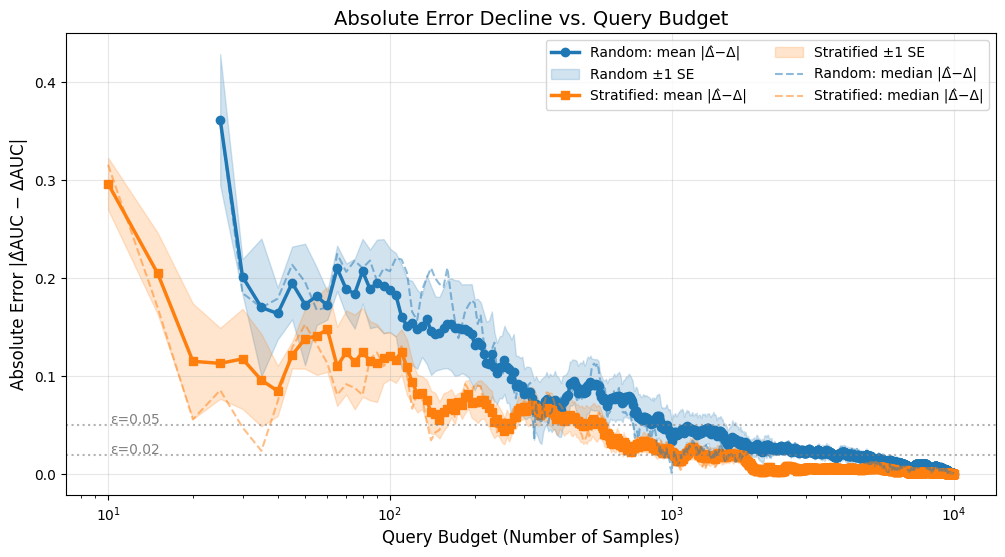

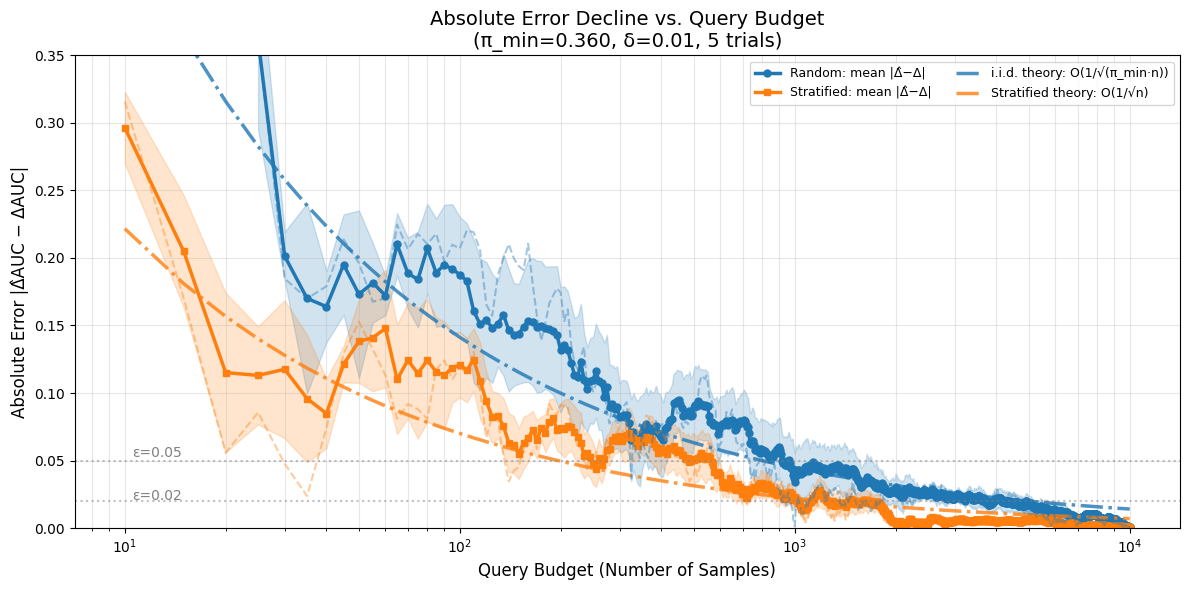

In [ ]:

def aggregate_abs_error(df_all, true_delta):
    """
    Expects columns: ['n_queries','delta_auc'] (+ 'seed' optional).
    Returns per-budget stats of |delta_auc - true_delta|.
    """
    df = df_all.copy()
    df['abs_err'] = (df['delta_auc'] - true_delta).abs()
    stats = (df.groupby('n_queries')['abs_err']
               .agg(['mean','std','count','median'])
               .reset_index())
    stats['se'] = stats['std'] / np.sqrt(stats['count'])
    return stats

mae_random = aggregate_abs_error(df_random_all, true_delta)
mae_strat  = aggregate_abs_error(df_stratified_all, true_delta)

# small epsilon to make bands visible if se==0
eps_band = 1e-6
se_rand  = np.maximum(mae_random['se'].to_numpy(), eps_band)
se_strat = np.maximum(mae_strat['se'].to_numpy(),  eps_band)

# PLOT: Absolute error decline 
fig, ax = plt.subplots(figsize=(12, 6))

# Random (blue)
ax.plot(mae_random['n_queries'], mae_random['mean'],
        'o-', linewidth=2.5, label='Random: mean |Δ̂−Δ|', color='C0')
ax.fill_between(mae_random['n_queries'],
                mae_random['mean'] - se_rand,
                mae_random['mean'] + se_rand,
                alpha=0.2, color='C0', label='Random ±1 SE')

# Stratified (orange)
ax.plot(mae_strat['n_queries'], mae_strat['mean'],
        's-', linewidth=2.5, label='Stratified: mean |Δ̂−Δ|', color='C1')
ax.fill_between(mae_strat['n_queries'],
                mae_strat['mean'] - se_strat,
                mae_strat['mean'] + se_strat,
                alpha=0.2, color='C1', label='Stratified ±1 SE')

ax.plot(mae_random['n_queries'], mae_random['median'],
        '--', alpha=0.5, color='C0', linewidth=1.5, label='Random: median |Δ̂−Δ|')
ax.plot(mae_strat['n_queries'], mae_strat['median'],
        '--', alpha=0.5, color='C1', linewidth=1.5, label='Stratified: median |Δ̂−Δ|')

for eps in [0.05, 0.02]:
    ax.axhline(eps, color='grey', linestyle=':', alpha=0.6)
    ax.text(mae_random['n_queries'].min()*1.02, eps*1.02, f'ε={eps}', color='grey')

ax.set_xscale('log')
ax.set_xlabel('Query Budget (Number of Samples)', fontsize=12)
ax.set_ylabel('Absolute Error |Δ̂AUC − ΔAUC|', fontsize=12)
ax.set_title('Absolute Error Decline vs. Query Budget', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, ncol=2)
# --> THEORY OVERLAY
def theory_eps(n, delta=0.05, K=2.0, scale=1.0, max_error=1.0):
    """
    Concentration bound: epsilon(n) = sqrt( K * log(4/delta) / (scale * n) )
    Capped at max_error since |Δ̂AUC - ΔAUC| ≤ 1.0
    
    Args:
        n: sample size
        delta: confidence parameter (probability of exceeding bound)
        K: constant from concentration inequality
        scale: scaling factor (e.g., 1/pi_min for i.i.d. sampling)
        max_error: maximum possible error (1.0 for ΔAUC)
    """
    n = np.asarray(n, dtype=float)
    eps = np.sqrt(K * np.log(4.0 / delta) / (scale * np.maximum(n, 1.0)))
    return np.minimum(eps, max_error)  # Cap at maximum possible error

# Compute pi_min from your dataset (minority group share)
pi_counts = D['group'].value_counts(normalize=True)
pi_min = float(pi_counts.min())

print(f"Minority group proportion: π_min = {pi_min:.3f}")

# tune this!
delta_theory = 0.01  # 99% confidence
K_strat = 0.082   # Constant from concentration inequality for stratified
K_iid   = 0.12   # Same order; i.i.d. differs by the 1/pi_min factor in scale

# X-axis points for theory curves (align to your budgets)
n_grid = np.array(sorted(set(mae_random['n_queries']).union(set(mae_strat['n_queries'])))) \
         if isinstance(mae_random, pd.DataFrame) else mae_random['n_queries'].to_numpy()

# Curves (now capped at 1.0)
eps_strat_theory = theory_eps(n_grid, delta=delta_theory, K=K_strat, scale=1.0, max_error=1.0)
eps_iid_theory   = theory_eps(n_grid, delta=delta_theory, K=K_iid,   scale=pi_min, max_error=1.0)

# Optional: theory bands to reflect constant uncertainty
K_low, K_high = 0.01, 1  # Reasonable range for concentration constants
band_strat_lo = theory_eps(n_grid, delta=delta_theory, K=K_low,  scale=1.0, max_error=1.0)
band_strat_hi = theory_eps(n_grid, delta=delta_theory, K=K_high, scale=1.0, max_error=1.0)
band_iid_lo   = theory_eps(n_grid, delta=delta_theory, K=K_low,  scale=pi_min, max_error=1.0)
band_iid_hi   = theory_eps(n_grid, delta=delta_theory, K=K_high, scale=pi_min, max_error=1.0)

# === PLOT OVER EXISTING ABS-ERROR FIG ========================================
fig, ax = plt.subplots(figsize=(12, 6))

# Random (blue)
ax.plot(mae_random['n_queries'], mae_random['mean'],
        'o-', linewidth=2.5, label='Random: mean |Δ̂−Δ|', color='C0', markersize=5)
ax.fill_between(mae_random['n_queries'],
                mae_random['mean'] - se_rand,
                mae_random['mean'] + se_rand,
                alpha=0.2, color='C0')

# Stratified (orange)
ax.plot(mae_strat['n_queries'], mae_strat['mean'],
        's-', linewidth=2.5, label='Stratified: mean |Δ̂−Δ|', color='C1', markersize=5)
ax.fill_between(mae_strat['n_queries'],
                mae_strat['mean'] - se_strat,
                mae_strat['mean'] + se_strat,
                alpha=0.2, color='C1')

# Theory curves
ax.plot(n_grid, eps_iid_theory,   '-.', linewidth=2.5, color='C0', 
        label=f'i.i.d. theory: O(1/√(π_min·n))', alpha=0.8)
ax.plot(n_grid, eps_strat_theory, '-.', linewidth=2.5, color='C1', 
        label='Stratified theory: O(1/√n)', alpha=0.8)
'''
# Light bands showing uncertainty in constants
ax.fill_between(n_grid, band_iid_lo, band_iid_hi,   
                color='C0', alpha=0.08, label='i.i.d. theory band')
ax.fill_between(n_grid, band_strat_lo, band_strat_hi, 
                color='C1', alpha=0.08, label='Stratified theory band')
'''
# Optional: show median as faint lines (robust to outliers)
ax.plot(mae_random['n_queries'], mae_random['median'],
        '--', alpha=0.4, color='C0', linewidth=1.5)
ax.plot(mae_strat['n_queries'], mae_strat['median'],
        '--', alpha=0.4, color='C1', linewidth=1.5)

# Reference error thresholds
for eps, label in [(0.05, 'ε=0.05'), (0.02, 'ε=0.02')]:
    ax.axhline(eps, color='grey', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.text(n_grid.min()*1.05, eps*1.05, label, color='grey', fontsize=10)

# Formatting
ax.set_xscale('log')
  # Log scale makes O(1/√n) behavior linear!
ax.set_xlabel('Query Budget (Number of Samples)', fontsize=12)
ax.set_ylabel('Absolute Error |Δ̂AUC − ΔAUC|', fontsize=12)
ax.set_title(f'Absolute Error Decline vs. Query Budget\n(π_min={pi_min:.3f}, δ={delta_theory}, {n_trials} trials)', 
             fontsize=14)

ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.set_ylim(0,0.35)

plt.tight_layout()
plt.show()

